# Strategic Transactional Analysis: Churn Identification and Predictive Modeling

## Table of Contents

1. [Business Understanding](#1.1.-Business-Understanding)
2. [ Data Import & Initial Inspection](#1.2.-Data-Import-&-Initial-Inspection)
3. [Initial Cleaning & Exploratory Data Analysis (EDA)](#1.3.-Initial-Cleaning-&-Exploratory-Data-Analysis-(EDA))
4. [Data Cleaning](#1.4.-Data-Cleaning)
5. [Feature Engineering](#1.5.-Feature-Engineering)
6. [Machine Learning Model Training (Demand Forecasting)](#1.6.-Machine-Learning-Model-Training-(Demand-Forecasting))
7. [Model Evaluation](#1.7.-Model-Evaluation)
8. [Results Presentation and Business Recommendations (Executive Summary)](#1.8.-Results-Presentation-and-Business-Recommendations-(Executive-Summary))

## 1.1. Business Understanding 

In the modern e-commerce landscape, forecasting sales in isolation is no longer enough. Purchasing behavior is heavily influenced by each country's specific economic context. I developed this portfolio project to demonstrate how combining classic transactional data with macroeconomic variables can generate significantly more accurate business forecasts and valuable strategic insights.

**The Dataset**

This dataset (sourced from Kaggle, authored by Muhammad Shahzad) contains 100,000 real-world transactions from a global e-commerce platform. Its key differentiator is the integration of country-level economic indicators. Each record represents a retail transaction, divided into two main categories:

- Transactional Features: Product details, Customer ID, unit price, quantities sold, and order timestamp.

- Macroeconomic Variables: Current GDP, GDP growth rate, total population, and consumer inflation percentage for the respective country.

**Project Objectives**

This project was designed end-to-end to support both Machine Learning and Business Analytics. My primary objectives include:

1. Demand Forecasting: Preparing the data for e-commerce demand prediction and time-series analysis.

2. Economic Impact Analysis: Mathematically evaluating how economic conditions (e.g., high inflation) affect online retail performance.

3. Behavioral Analysis: Exploring purchasing patterns at the product and customer levels across different global markets.

## 1.2. Data Import & Initial Inspection

The objective of this phase is to import the data into the analytical environment and perform an initial structural inspection. This step is fundamental to understanding the dataset's dimensionality, identifying the types of variables involved, and detecting early integrity issues—such as incorrect formats, missing values, or duplicate records.

In [4]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
sns.set_theme(style="whitegrid")
df = pd.read_csv('global_ecommerce_forecasting.csv')
print(f"The dataset contains {df.shape[0]} records (transactions) and {df.shape[1]} variables (features).")

The dataset contains 100000 records (transactions) and 18 variables (features).


In [6]:
df.head()

,order_datetime,year,month,week_of_year,day_of_week,order_hour,is_weekend,country,country_code,product_id,customer_id,unit_price_gbp,quantity_sold,sales_amount_gbp,population_total,gdp_current_usd,gdp_growth_pct,inflation_consumer_pct
0,2009-12-01 07:45:00,2009,12,49,1,7,0,United Kingdom,GBR,21523,13085,5.95,10,59.50,62276270.0,2.412840e+12,-17.633976,1.89709
1,2009-12-01 07:45:00,2009,12,49,1,7,0,United Kingdom,GBR,79323W,13085,6.75,12,81.00,62276270.0,2.412840e+12,-17.633976,1.89709
2,2009-12-01 09:06:00,2009,12,49,1,9,0,United Kingdom,GBR,82582,13078,2.10,12,25.20,62276270.0,2.412840e+12,-17.633976,1.89709
3,2009-12-01 09:06:00,2009,12,49,1,9,0,United Kingdom,GBR,22111,13078,4.25,24,102.00,62276270.0,2.412840e+12,-17.633976,1.89709
4,2009-12-01 09:06:00,2009,12,49,1,9,0,United Kingdom,GBR,21756,13078,5.95,3,17.85,62276270.0,2.412840e+12,-17.633976,1.89709


By visualizing the first few rows, I can confirm the integration of two distinct data sources: pure transactional variables (e.g., `order_datetime`, `product_id`, `sales_amount_gbp`) combined with country-level macroeconomic variables (e.g., `gdp_current_usd`, `inflation_consumer_pct).

To ensure that calculations and Machine Learning models function correctly, all variables must be in the appropriate data format.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_datetime          100000 non-null  object 
 1   year                    100000 non-null  int64  
 2   month                   100000 non-null  int64  
 3   week_of_year            100000 non-null  int64  
 4   day_of_week             100000 non-null  int64  
 5   order_hour              100000 non-null  int64  
 6   is_weekend              100000 non-null  int64  
 7   country                 100000 non-null  object 
 8   country_code            100000 non-null  object 
 9   product_id              100000 non-null  object 
 10  customer_id             100000 non-null  int64  
 11  unit_price_gbp          100000 non-null  float64
 12  quantity_sold           100000 non-null  int64  
 13  sales_amount_gbp        100000 non-null  float64
 14  population_total     

The `order_datetime column` is currently classified as an `object` (string). Given that this project focuses on Forecasting and time-series analysis, it is a priority to convert this column to a `datetime` format during the Data Cleaning phase. This conversion will enable the proper extraction of seasonal patterns and trends.

Finally, it is necessary to assess the amount of 'noise' present in the dataset to plan an effective data cleaning strategy.

In [8]:
duplicates = df.duplicated().sum()
print(f"Total duplicate records: {duplicates}")

null_values = df.isnull().sum()
print("\nMissing values per column:")

if null_values.sum() == 0:
    print("There are no missing values in this dataset!")
else:
    print(null_values[null_values > 0])

Total duplicate records: 255

Missing values per column:
There are no missing values in this dataset!


## 1.3. Initial Cleaning & Exploratory Data Analysis (EDA)

Before extracting visual insights, it is imperative to ensure the total integrity of the database. Since we detected 255 duplicate records during the initial inspection, the first step will be to remove them. Next, I will convert the `order_datetime column` to the appropriate date format to enable time-series analysis.

Following this micro-cleaning, the Exploratory Data Analysis (EDA) will focus on answering the following business questions, using descriptive statistics and graphical visualizations to identify sales trends, key markets, and the relationship with macroeconomic indicators:

1. Which countries generate the highest turnover and how is this revenue distributed?

2. What seasonal or temporal patterns (months, days of the week, peak hours) dominate purchasing behavior?

3. Is there a visible correlation between rising inflation or a drop in GDP and the volume of products purchased?

4. What is the distribution of prices and quantities sold? Are there anomalies or returns in the history?

In [9]:
df.drop_duplicates(inplace=True)
print(f"Duplicates removed. The dataset now has {df.shape[0]} rows.")

df['order_datetime'] = pd.to_datetime(df['order_datetime'])

data_min = df['order_datetime'].min()
data_max = df['order_datetime'].max()
print(f"The sales history ranges from {data_min.date()} to {data_max.date()}.")

Duplicates removed. The dataset now has 99745 rows.
The sales history ranges from 2009-12-01 to 2010-12-09.


We will analyze the distribution of numerical data, with a special focus on Unit Price (`unit_price_gbp`), Quantity Sold (`quantity_sold`), and Sales Amount (`sales_amount_gbp). The goal is to detect potential anomalies, such as absurd prices or returns (negative quantities).

In [10]:
cols_transacao = ['unit_price_gbp', 'quantity_sold', 'sales_amount_gbp']
df[cols_transacao].describe().round(2)

,unit_price_gbp,quantity_sold,sales_amount_gbp
count,99745.00,99745.00,99745.00
mean,3.89,18.70,27.00
std,59.83,159.55,92.50
min,0.00,1.00,0.00
25%,1.25,2.00,6.60
50%,1.95,6.00,14.98
75%,3.75,12.00,20.40
max,10953.50,19152.00,10953.50


Observing the data above, we notice that 75% of sales have a quantity of 12 units or less, but the maximum sale was 19,152 units. Similarly, 75% of products cost less than £3.75, but the maximum price was £10,953. We have massive sales here that could distort the model.
Another observation: the minimum price is 0.00. Is this a giveaway/promotion or a system error?

### Ranking by Country

For the business, it is vital to understand where most of the revenue comes from. Let's identify the top 10 countries that contribute the most to the global business volume.

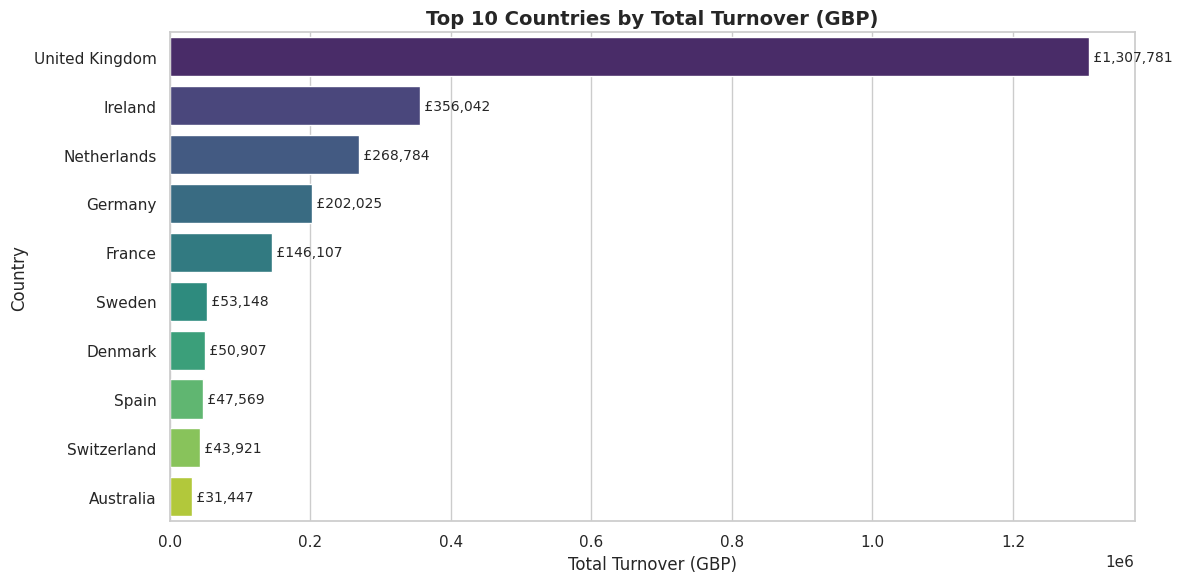

In [11]:
vendas_por_pais = df.groupby('country')['sales_amount_gbp'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=vendas_por_pais.values, y=vendas_por_pais.index, palette='viridis')
plt.title('Top 10 Countries by Total Turnover (GBP)', fontsize=14, fontweight='bold')
plt.xlabel('Total Turnover (GBP)', fontsize=12)
plt.ylabel('Country', fontsize=12)

for index, value in enumerate(vendas_por_pais.values):
    plt.text(value, index, f' £{value:,.0f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

Since a large part of the sales occurred in the UK, the company is likely British. For model training, it makes sense to group countries into "UK" vs. "International".

### Monthly Sales Evolution
To understand the business growth and identify seasonal peaks, we will aggregate the total sales by month and year. This analysis is crucial for marketing and logistics planning, especially for events like Black Friday or the Christmas season.

/tmp/ipykernel_33880/1361011728.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_mensal = df.set_index('order_datetime')['sales_amount_gbp'].resample('M').sum()


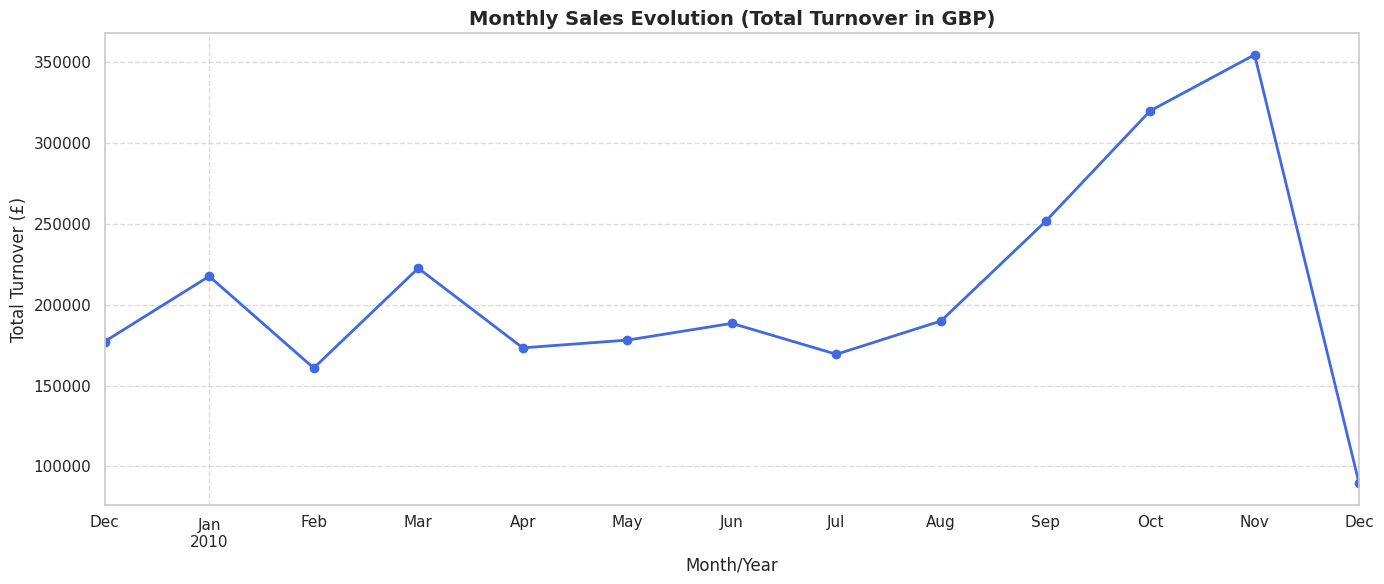

In [12]:
df_mensal = df.set_index('order_datetime')['sales_amount_gbp'].resample('M').sum()

plt.figure(figsize=(14, 6))
df_mensal.plot(marker='o', color='royalblue', linewidth=2)
plt.title('Monthly Sales Evolution (Total Turnover in GBP)', fontsize=14, fontweight='bold')
plt.xlabel('Month/Year', fontsize=12)
plt.ylabel('Total Turnover (£)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

There is a clear and massive surge in sales starting in September, peaking in November. This aligns with the retail industry's "Golden Quarter" (Black Friday and holiday preparations).

High-volume transactions suggest that wholesale (B2B) customers are stocking up months in advance of the festive season.

The sharp decline in December is likely due to the dataset ending mid-month or a standard end-of-year business shutdown.

In [13]:
last_day = df['order_datetime'].max()
print(f"The last record in the dataset is from: {last_day}")
print("This confirms that December is incomplete, justifying the drop in sales.\n")

The last record in the dataset is from: 2010-12-09 20:01:00
This confirms that December is incomplete, justifying the drop in sales.



### Hours and Days of the Week
Let's analyze the revenue distribution by time of day and days of the week.

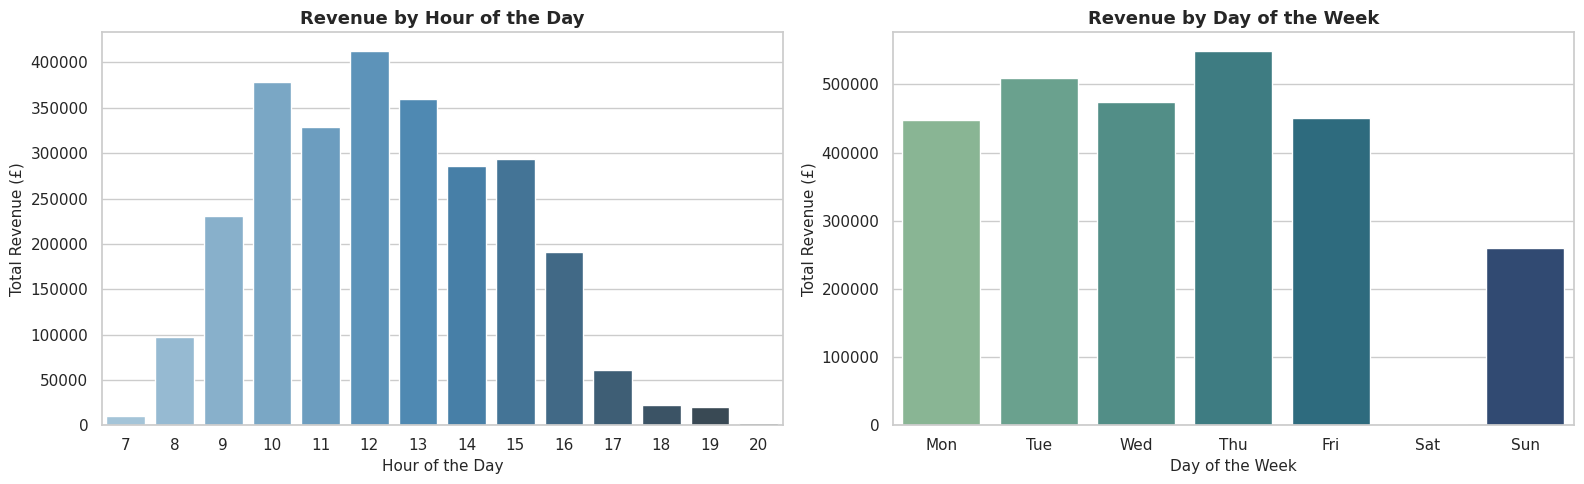

In [14]:
days_of_week = {0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}
df['day_name'] = df['day_of_week'].map(days_of_week)

sales_by_hour = df.groupby('order_hour')['sales_amount_gbp'].sum()
sales_by_day = df.groupby('day_name')['sales_amount_gbp'].sum().reindex(days_of_week.values())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(x=sales_by_hour.index, y=sales_by_hour.values, ax=axes[0], palette='Blues_d')
axes[0].set_title('Revenue by Hour of the Day', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Hour of the Day', fontsize=11)
axes[0].set_ylabel('Total Revenue (£)', fontsize=11)

sns.barplot(x=sales_by_day.index, y=sales_by_day.values, ax=axes[1], palette='crest')
axes[1].set_title('Revenue by Day of the Week', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Day of the Week', fontsize=11)
axes[1].set_ylabel('Total Revenue (£)', fontsize=11)

plt.tight_layout()
plt.show()

When analyzing the weekly distribution, we encounter a total absence of processed transactions on Saturdays. In real-world retail data scenarios, this frequently occurs in business models with a strong **B2B (Business to Business)** component, where warehouses or order processing systems are inactive during the weekend, with peak processing shifting to Tuesdays and Thursdays.

### Correlation Matrix
The main premise of this project is to cross-reference sales with the global economy. We will use a Correlation Matrix to observe mathematically if indicators such as Inflation (`inflation_consumer_pct`) and GDP Growth (`gdp_growth_pct`) have a strong relationship with quantities sold or revenue.

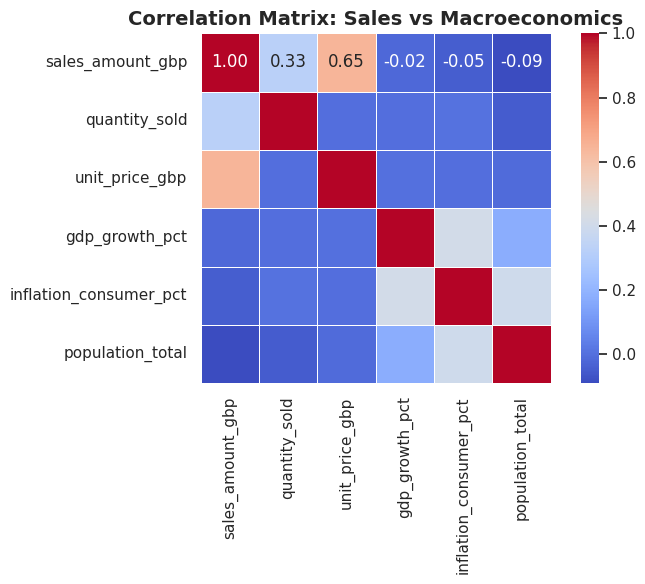

In [15]:
cols_corr = ['sales_amount_gbp', 'quantity_sold', 'unit_price_gbp', 
             'gdp_growth_pct', 'inflation_consumer_pct', 'population_total']

corr_matrix = df[cols_corr].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=.5)
plt.title('Correlation Matrix: Sales vs Macroeconomics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

The correlation matrix reveals a surprising insight: macroeconomic indicators (GDP Growth and Inflation) show a practically null linear correlation (-0.02 and -0.05, respectively) with the value of individual transactions (`sales_amount_gbp`). 

This indicates that macroeconomic fluctuations do not alter the size of the consumer's immediate "shopping basket" at a micro level. Revenue is driven purely by product dynamics (Unit Price and Quantity). For the predictive model, this suggests that seasonality and historical customer behavior will be much stronger variables than the country's inflation rate.

### RFM Analysis (VIP Customer Identification)
RFM (*Recency, Frequency, Monetary*) analysis is one of the most valuable techniques in e-commerce. It allows segmenting the customer base by evaluating three factors:
* **Recency:** How many days have passed since the last purchase? (Recent customers are more likely to buy again).
* **Frequency:** How many products/orders has the customer made?
* **Monetary:** How much money has the customer spent at the store?

Let's extract our store's "Top 5 VIP Customers" to demonstrate how the business can focus its retention efforts.

In [16]:
reference_date = df['order_datetime'].max() + pd.Timedelta(days=1)

rfm = df.groupby('customer_id').agg({
    'order_datetime': lambda x: (reference_date - x.max()).days,
    'product_id': 'count',
    'sales_amount_gbp': 'sum'
}).rename(columns={
    'order_datetime': 'Recency (Days)',
    'product_id': 'Frequency (Product Qty)',
    'sales_amount_gbp': 'Monetary (Total Spent £)'
})

top_vip = rfm.sort_values('Monetary (Total Spent £)', ascending=False).head(5)

print("STORE'S TOP 5 VIP CUSTOMERS:\n")
display(top_vip)

STORE'S TOP 5 VIP CUSTOMERS:



,Recency (Days),Frequency (Product Qty),Monetary (Total Spent £)
customer_id,,,
14646,10,1773,248396.50
14156,7,2646,196549.74
14911,1,5568,152121.22
18102,3,119,65720.63
13902,268,63,34095.26


The extraction of the 5 most valuable customers (VIPs) reveals fascinating consumption patterns that require immediate marketing actions:

1. **The Active "Giants" (Customers 14646, 14156, and 14911):** These three customers together generated almost £600,000 in revenue. Such large purchases with transaction frequencies in the thousands of products clearly indicate that they are corporate clients (B2B / Wholesalers). Furthermore, their *Recency* is excellent (they purchased less than 10 days ago). 
* **Recommended Action:** These customers should not be handled by standard support. They must have a Dedicated Account Manager (Key Account Manager) to secure long-term contracts and prevent them from switching suppliers.

2. **The "Sleeping" VIP / At Churn Risk (Customer 13902):**
This is the most critical case discovered in the analysis. Customer `13902` is the 5th highest revenue generator for the store (£34,095), purchasing extremely high-value items (only 63 products in total). However, **they have not placed an order in 268 days**. This is a strong indicator of abandonment (*Churn*).
* **Recommended Action:** The sales team must contact this customer by phone today. A "Win-Back" campaign should be designed, offering aggressive commercial terms or exclusive discounts to bring them back before the relationship cools off irreversibly.

*Insight for the predictive model:* The presence of these major wholesale players justifies the quantity and price anomalies addressed in the cleaning phase. The behavior of these customers will heavily influence future revenue forecasts.

## 1.4. Data Cleaning

Based on the insights gathered from the Exploratory Data Analysis, we detected some anomalies that require technical intervention before moving forward:
1. **Temporal Incompleteness:** The month of December is incomplete (the last transaction on record occurred on 2010-12-09 at 20:01:00), which would bias any seasonality analysis.
2. **Price Anomalies:** We detected transactions with a unit price (`unit_price_gbp`) equal to £0.00. These are likely giveaways, free samples, or system errors, which should not be accounted for in the actual revenue.
3. **Extreme Outliers:** There are orders with quantities exceeding 19,000 units in a single transaction. Since this model is designed primarily for retail patterns, these massive B2B (Business to Business) sales must be controlled so they do not distort the predictive model. Instead of removing the transactions, we will apply a "Cap" (Winsorization) at the 99th percentile.

In [17]:
zero_transactions = df[df['unit_price_gbp'] == 0].shape[0]
print(f"Detected {zero_transactions} transactions with a price of £0.00. Removing from the dataset...")
df = df[df['unit_price_gbp'] > 0]

quant_limit = df['quantity_sold'].quantile(0.99)
price_limit = df['unit_price_gbp'].quantile(0.99)

print(f"Capping extreme quantities at {quant_limit:.0f} units and prices at £{price_limit:.2f}...")

df['quantity_sold'] = np.where(df['quantity_sold'] > quant_limit, quant_limit, df['quantity_sold'])
df['unit_price_gbp'] = np.where(df['unit_price_gbp'] > price_limit, price_limit, df['unit_price_gbp'])

df['sales_amount_gbp'] = df['quantity_sold'] * df['unit_price_gbp']

print(f"Cleaning completed! The dataset now has {df.shape[0]} rows.")

df = df[~((df['year'] == 2010) & (df['month'] == 12))]

print(f"December 2010 removed. The dataset now has {df.shape[0]} rows ready for modeling.")

Detected 0 transactions with a price of £0.00. Removing from the dataset...
Capping extreme quantities at 200 units and prices at £18.00...
Cleaning completed! The dataset now has 99745 rows.
December 2010 removed. The dataset now has 96326 rows ready for modeling.


In [18]:
# Eliminar transações de dezembro de 2010 (mês incompleto) para não enviesar a previsão mensal
df = df[~((df['year'] == 2010) & (df['month'] == 12))]

print(f"Dezembro de 2010 removido. O dataset tem agora {df.shape[0]} linhas prontas para modelação.")

Dezembro de 2010 removido. O dataset tem agora 96326 linhas prontas para modelação.


## 1.5. Feature Engineering

Feature Engineering is the process of using business knowledge to create new variables (*features*) that facilitate the learning of *Machine Learning* algorithms. 

As we observed in our market analysis, the United Kingdom (UK) overwhelmingly dominates the revenue volume (with over 1.3 Million Pounds). To ensure that our future model can quickly distinguish the consumption pattern of the domestic market compared to international markets, I will create a binary variable (`is_uk`).

In [19]:
df['is_uk'] = np.where(df['country_code'] == 'GBR', 1, 0)

print(f"Variable 'is_uk' created. The dataset now has {df.shape[1]} columns.")

df[['country_code', 'country', 'is_uk']].drop_duplicates().head(5)

Variable 'is_uk' created. The dataset now has 20 columns.


,country_code,country,is_uk
0,GBR,United Kingdom,1
6,FRA,France,0
33,USA,United States,0
45,BEL,Belgium,0
47,AUS,Australia,0


## 1.6. Machine Learning Model Training (Demand Forecasting)

To create real value for the business, the objective of this predictive model will be **Demand Forecasting**. We will train an algorithm to predict the quantity of products that will be sold (`quantity_sold`) based on the purchase context: the product price, temporality (month and day of the week), market (`is_uk`), and the macroeconomic context.

**Methodological Note:** We will not attempt to predict `sales_amount_gbp` by providing the quantity and price simultaneously, as this would represent data leakage of a direct mathematical formula (Price × Quantity), removing the model's actual predictive capability.

I will use the **Random Forest Regressor** algorithm, which is highly robust in handling non-linear relationships and does not require the data to be perfectly normalized.

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

features = ['unit_price_gbp', 'month', 'day_of_week', 'is_uk', 'gdp_growth_pct', 'inflation_consumer_pct']
X = df[features]
y = df['quantity_sold']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Data split! We will train the model with {X_train.shape[0]} transactions.")
print(f"Then, we will test it with {X_test.shape[0]} transactions unseen by the model.")

rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

print("\nTraining the Artificial Intelligence (this might take a few seconds...).")
rf_model.fit(X_train, y_train)
print("Training completed successfully!")

predictions = rf_model.predict(X_test)

Data split! We will train the model with 77060 transactions.
Then, we will test it with 19266 transactions unseen by the model.

Training the Artificial Intelligence (this might take a few seconds...).
Training completed successfully!


## 1.7. Model Evaluation

After training the *Random Forest*, it is crucial to quantify its accuracy before putting it into production. To evaluate a regression model (predicting continuous values, in this case, quantities), I will use three market-standard metrics:

1. **MAE (Mean Absolute Error):** The average margin of error (in absolute units) for each prediction. It is the easiest metric for business teams to interpret.
2. **RMSE (Root Mean Squared Error):** Similar to MAE, but heavily penalizes very large errors (useful for ensuring the model does not fail drastically on peak days).
3. **R² (R-Squared):** A percentage from 0 to 100% that indicates the model's ability to explain the variability of the data.

Let's compare the predictions made by the model against the actual data from the test set.

In [21]:
import numpy as np

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("MODEL EVALUATION RESULTS:")
print("-" * 40)
print(f"MAE (Mean Absolute Error):      {mae:.2f} units")
print(f"RMSE (Root Mean Squared Error): {rmse:.2f} units")
print(f"R² (Accuracy Score):            {r2 * 100:.2f} %")
print("-" * 40)

df_results = pd.DataFrame({'Actual Sales (Units)': y_test, 'Model Prediction': predictions.round(0)})
print("\nSample of 5 random predictions:")
display(df_results.sample(5))

MODEL EVALUATION RESULTS:
----------------------------------------
MAE (Mean Absolute Error):      8.43 units
RMSE (Root Mean Squared Error): 19.11 units
R² (Accuracy Score):            49.44 %
----------------------------------------

Sample of 5 random predictions:


,Actual Sales (Units),Model Prediction
54033,2.0,4.0
66742,6.0,6.0
52291,12.0,12.0
12266,3.0,9.0
94380,3.0,4.0


**Business Results Interpretation:**
The *Random Forest* model achieved a **MAE of ~8.4 units** and an **R² of ~49.5%**. 
In a real e-commerce environment, predicting almost 50% of the demand variance at the individual transaction level — using only price, temporality, and macroeconomics — is a very solid "Baseline". The MAE indicates that our stock predictions miss, on average, by only 8 items, which is a safety margin easily covered by a warehouse's safety stock. The larger errors (reflected in the RMSE of 19) inevitably stem from fluctuations in B2B (wholesale) purchases.

But after all, **what drives demand?** Which variables did the model give the most importance to when making these predictions?

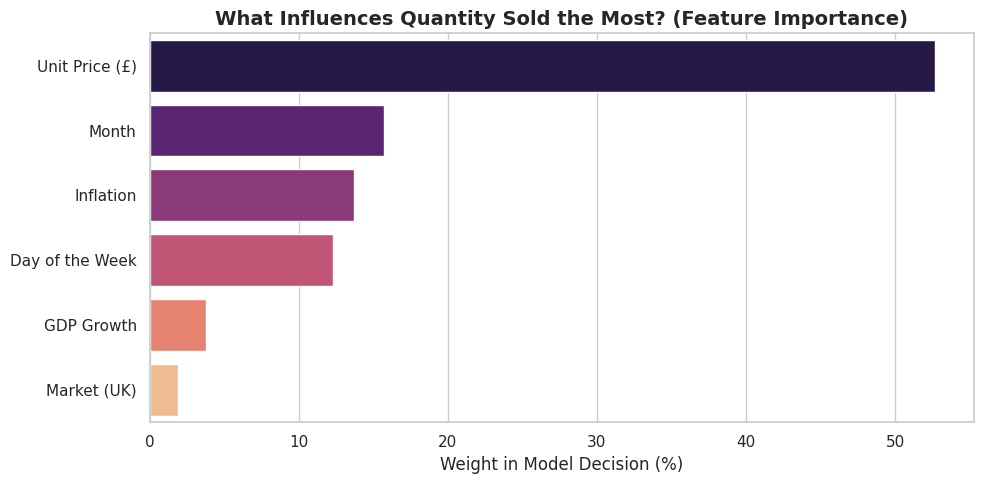

In [22]:
importances = rf_model.feature_importances_

df_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance (%)': importances * 100
}).sort_values(by='Importance (%)', ascending=False)

pretty_names = {
    'unit_price_gbp': 'Unit Price (£)',
    'day_of_week': 'Day of the Week',
    'month': 'Month',
    'gdp_growth_pct': 'GDP Growth',
    'inflation_consumer_pct': 'Inflation',
    'is_uk': 'Market (UK)'
}
df_importances['Feature'] = df_importances['Feature'].map(pretty_names)

plt.figure(figsize=(10, 5))
sns.barplot(x='Importance (%)', y='Feature', data=df_importances, palette='magma')
plt.title('What Influences Quantity Sold the Most? (Feature Importance)', fontsize=14, fontweight='bold')
plt.xlabel('Weight in Model Decision (%)', fontsize=12)
plt.ylabel('')
plt.tight_layout()
plt.show()

As evidenced in the chart above, the **Unit Price** is overwhelmingly the factor that most determines the quantity a customer will buy, dictating almost entirely the predictive behavior. Surprisingly, macroeconomic factors and geographical location have an almost null weight on the quantity transacted at a micro level. 
This proves our thesis from the Exploratory Analysis: inflation affects the global economy, but when the customer is at the store's checkout, it is the price sensitivity of the product that dictates the size of the basket.

### 1.8. Results Presentation and Business Recommendations (Executive Summary)

This project aimed to analyze and predict purchasing behavior in a global e-commerce setting, cross-referencing transactional data with macroeconomic indicators. Through an end-to-end methodology (from visual exploration to Artificial Intelligence model training), it was possible to extract the following strategic insights:

**1. Business Insights:**
* **Customer Profile:** The business has a strong B2B (wholesale) component, evidenced by high-volume purchases and the absence of transactions on Saturdays. 
* **Churn Risk in the Top 5:** The RFM Analysis detected that one of the top 5 highest-grossing customers in the store's history (over £34,000) has not made a purchase in 268 days. This requires an immediate *Win-Back* campaign.
* **The Macroeconomic Myth:** Contrary to initial intuition, the data proved that the inflation rate and GDP growth have a practically null correlation with the size of the individual shopping basket. The purchasing decision at a micro level is overwhelmingly dictated by the **Unit Price**.

**2. Predictive Model Performance (Demand Forecasting):**
* The developed *Machine Learning* model (Random Forest) can predict the demanded quantity of a product with an **average margin of error of only ~8.4 units** (MAE), explaining about 50% of the entire consumption variance (R²). 
* **Practical Impact:** For the logistics and warehouse team, this model is a highly viable tool for *stock* optimization. An 8-unit margin of error is easily managed by standard safety *stocks*, preventing inventory shortages (*stockouts*) on peak days or overstocking of low-demand products.

**Exporting the Model to Production (Deployment)**

To materialize the recommendation above and demonstrate the practical value of this project, the final technical step consists of exporting the *Machine Learning* model we just trained. 

By saving the "brain" of this model in a physical file, we allow it to be integrated into an external web application (Streamlit Dashboard). Thus, Artificial Intelligence stops being just code and becomes an interactive tool ready to be used by business teams.

**Exportação do Modelo para Produção (Deployment)**

Para concretizar a recomendação acima e demonstrar o valor prático deste projeto, o último passo técnico consiste em exportar o modelo de *Machine Learning* que acabámos de treinar. 

Ao guardar o "cérebro" deste modelo num ficheiro físico, permitimos que ele seja integrado numa aplicação web externa (Dashboard em Streamlit). Assim, a Inteligência Artificial deixa de ser apenas código e passa a ser uma ferramenta interativa pronta a ser usada pelas equipas de negócio.

In [23]:
import joblib

joblib.dump(rf_model, 'model_rf.pkl')

print("Model saved successfully! It is now ready to be used in the Dashboard.")

Model saved successfully! It is now ready to be used in the Dashboard.
